In [14]:
import pylab as pl
import numpy as np
from matplotlib.ticker import MultipleLocator, LogLocator, ScalarFormatter, FormatStrFormatter
import matplotlib.ticker as mticker
import copy
import math
from matplotlib.ticker import FuncFormatter
import os
import time
import re
import pylab as pl
import numpy as np
import pylab as pl

from datetime import datetime, timedelta

import pandas as pd

import shutil
import matplotlib.ticker as mticker

from matplotlib.ticker import FuncFormatter
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

import math

formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 2)) 
formatter.set_useOffset(False)

In [46]:
SMALL_SIZE = 27
MEDIUM_SIZE = 80
BIGGER_SIZE = 22

pl.rc('font', size=BIGGER_SIZE)          # controls default text sizes
pl.rc('axes', titlesize=45)     # fontsize of the axes title
pl.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
pl.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
pl.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
pl.rc('legend', fontsize=45)    # legend fontsize
pl.rc('figure', titlesize=BIGGER_SIZE) 


In [3]:
# (1445200-857400)/(140-80), (1838400-1050600)/(140-80), (2316990- 1333641)/(140-80),\
# (2617800-1503000)/(140-80), (2831801-1627501)/ (140-80), (2796297-1608597)/ (140-80)

In [4]:
resdb_thputs_24 = [9796, 13130, 16389, 18580, 20071, 19795]
resdb_lats_24 = [1.04, 0.68, 0.69, 0.45, 0.46, 0.47]

In [5]:
resdb_thputs = [14400.0, 15739, 13191]
hs_thputs = [29737, 17010, 8015]

bft_mc_thputs = [1062,818,952]

resdb_lats = [0.32, 0.26, 0.38]
hs_lats = [0.16, 0.29, 0.64]

bft_mc_lats = [0.02, 0.041, 0.045]



In [6]:
resdb_geo_folders = ['resdb_48_12_2cls_async400_geo/',\
                    'resdb_48_12_3cls_async400_geo/',\
                    'resdb_48_12_4cls_async400_geo/',\
                    'resdb_48_12_6cls_async400_geo/',\
                    'resdb_48_12_8cls_async400_geo/',\
                    'resdb_48_12_12cls_async400_geo/']

In [7]:
resdb_lats_geo_24 = []
for folder in resdb_geo_folders:
    print(folder)
    average_latency_values = []
    for file in os.listdir('Experiments/'+folder):
        if 'client' in file:
            latency_values = []
            with open('Experiments/'+folder+file, "r", encoding="utf-8", errors="ignore") as file:
                for line in file:
    #                 print(line)
                    if line.startswith("Latency="):  # Match the Latency line
                        value = line.split("=")[1].strip()
                        latency_values.append(float(value) if value != "-nan" else None)
#             print(np.average(latency_values[20:-1]))
            average_latency_values.append(np.average(latency_values[20:-1]))
    #         break
    print('average latency is ',np.average(average_latency_values))
    resdb_lats_geo_24.append(np.average(average_latency_values))
    
resdb_lats_geo_24

resdb_48_12_2cls_async400_geo/
average latency is  0.9790118562648239
resdb_48_12_3cls_async400_geo/
average latency is  0.7362919209199963
resdb_48_12_4cls_async400_geo/
average latency is  0.7958000519046858
resdb_48_12_6cls_async400_geo/
average latency is  0.6318087423029557
resdb_48_12_8cls_async400_geo/
average latency is  0.5617317101103053
resdb_48_12_12cls_async400_geo/
average latency is  0.6053866957538924


[0.9790118562648239,
 0.7362919209199963,
 0.7958000519046858,
 0.6318087423029557,
 0.5617317101103053,
 0.6053866957538924]

In [8]:
resdb_thputs_geo_24 = []
for folder in resdb_geo_folders:
    print(folder)
    txn_counts = {}
    with open('Experiments/'+folder+'nohup_server_0.out', "r", encoding="utf-8", errors="ignore") as file:
        total_runtime = None
        txn_cnt_values = []  # Store txn_cnt values for the current runtime block

        for line in file:
            # Match total_runtime
            runtime_match = re.search(r"total_runtime=([\d.]+)", line)
            if runtime_match:
                total_runtime = float(runtime_match.group(1))  # Convert runtime to float
                txn_cnt_values = []  # Reset txn_cnt list for this runtime

            # Match txn_cnt values
            txn_match = re.search(r"txn_cnt=(\d+)", line)
            if txn_match:
                txn_cnt_values.append(int(txn_match.group(1)))

            # Store the second txn_cnt when available
            if total_runtime is not None and len(txn_cnt_values) == 2:
                txn_counts[int(total_runtime)] = txn_cnt_values[1] 
                
        requested_runtimes = [140, 80]
#         print(txn_counts)
#         for runtime in requested_runtimes:
#             print(f"Second txn_cnt for total_runtime={runtime}s:", txn_counts.get(runtime, "Not Found"))
    average_thput = (txn_counts.get(requested_runtimes[0])-txn_counts.get(requested_runtimes[1]))/ \
    (requested_runtimes[0]-requested_runtimes[1])
    print('average throughput is ',average_thput)
    resdb_thputs_geo_24.append(average_thput)
resdb_thputs_geo_24

resdb_48_12_2cls_async400_geo/
average throughput is  9866.666666666666
resdb_48_12_3cls_async400_geo/
average throughput is  13011.666666666666
resdb_48_12_4cls_async400_geo/
average throughput is  15466.666666666666
resdb_48_12_6cls_async400_geo/
average throughput is  17933.783333333333
resdb_48_12_8cls_async400_geo/
average throughput is  17653.333333333332
resdb_48_12_12cls_async400_geo/
average throughput is  15555.483333333334


[9866.666666666666,
 13011.666666666666,
 15466.666666666666,
 17933.783333333333,
 17653.333333333332,
 15555.483333333334]

In [9]:
# 2, 3, 4,6,8, 12
hs_thputs_24 = [4887, 7113, 9850, 15232, 18117, 27474]
hs_lats_24 = [1.96, 1.35, 0.97,0.63, 0.52, 0.35]

In [10]:
#3, 4, 6,8,12
hs_thputs_24_geo = [5572 ,8948, 12109,18506, 21073, 27255]
hs_lats_24_geo = [1.72 ,1.07, 0.79,0.52, 0.45, 0.35]

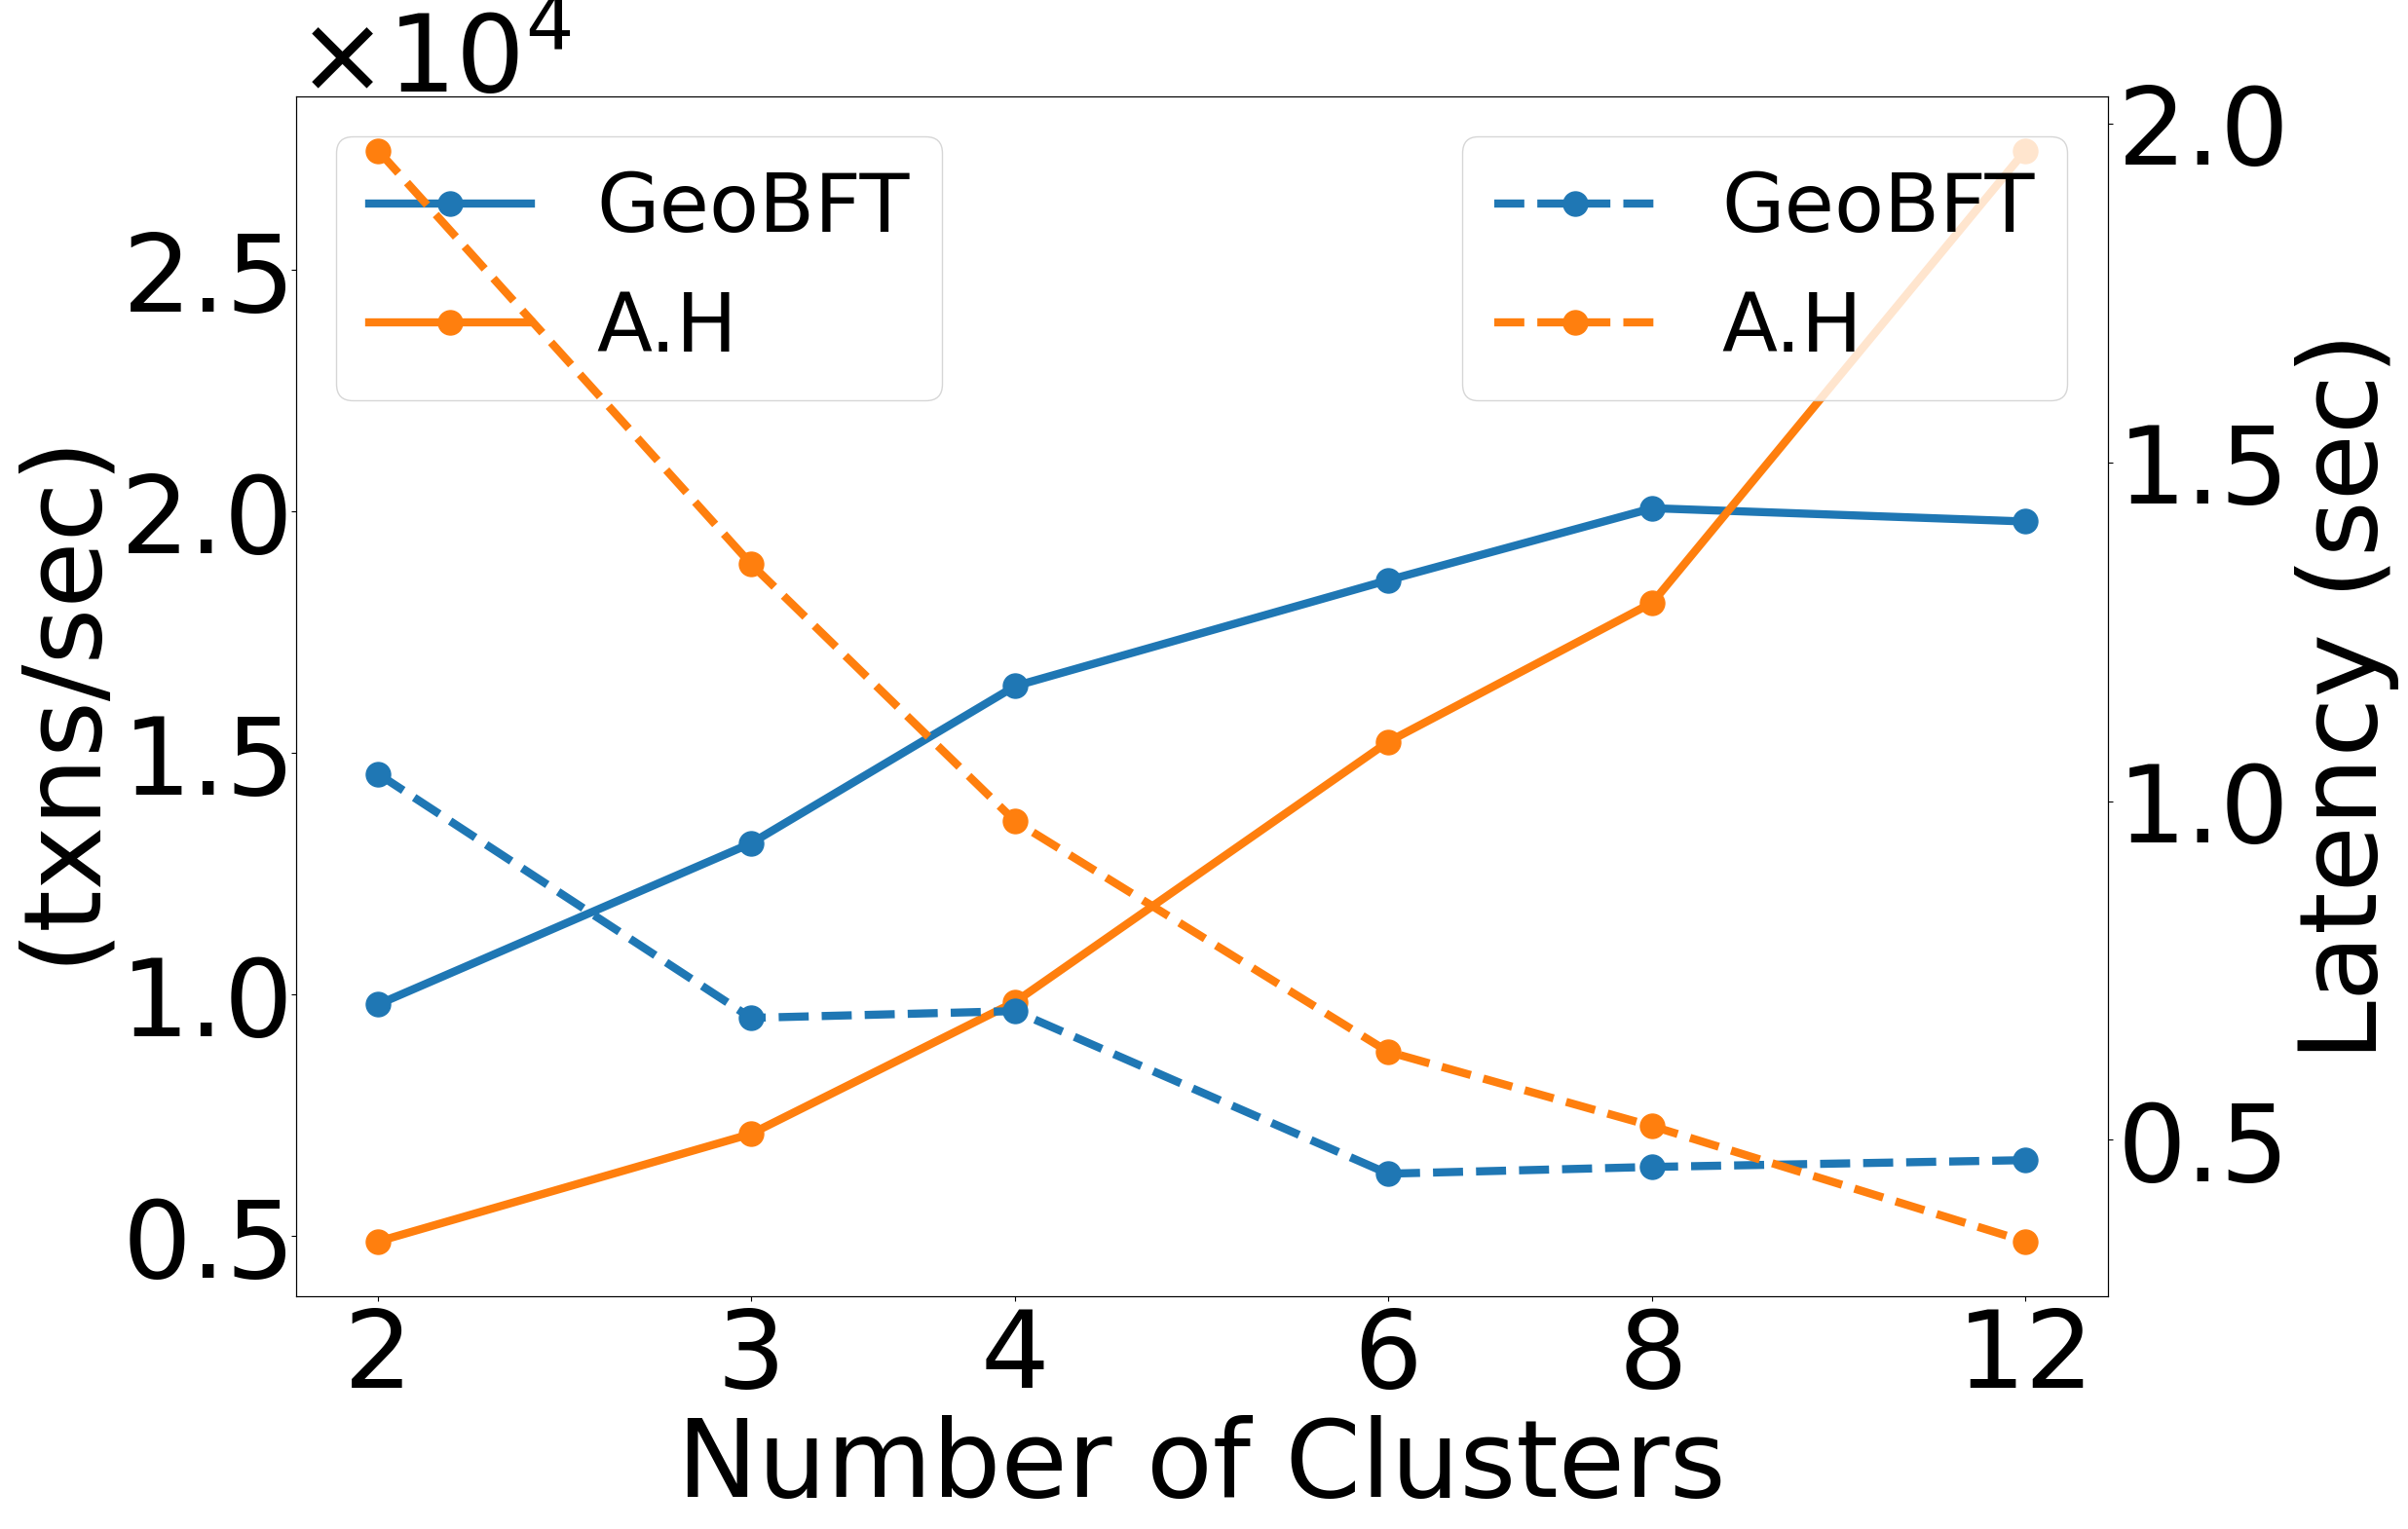

<Figure size 640x480 with 0 Axes>

In [56]:
fig, ax1 = pl.subplots(figsize=(24, 16))
ax1.plot([2, 3, 4, 6, 8, 12], resdb_thputs_24, '-o', label='GeoBFT', markersize = 18, linewidth=6)
ax1.plot([2, 3, 4, 6, 8, 12], hs_thputs_24, '-o', label='A.H', markersize = 18, linewidth=6)

ax1.legend(fontsize=45)
ax1.set_xscale('log')
ax1.yaxis.set_major_formatter(formatter)

# Define and set only specific tick positions
ticks = [2, 3, 4, 6, 8, 12]

ax1.set_xticks(ticks)
ax1.set_xticklabels([str(tick) for tick in ticks])


pl.xlabel('Number of Clusters')
ax1.set_ylabel('(txns/sec)')

# Ensure no unwanted minor ticks appear
ax1.xaxis.set_minor_locator(pl.NullLocator())  
ax1.xaxis.set_major_formatter(pl.ScalarFormatter())  

ax2 = ax1.twinx()



ax2.plot([2, 3, 4, 6, 8, 12], resdb_lats_24, '--o', label='GeoBFT', markersize = 18, linewidth=6)
ax2.plot([2, 3, 4, 6, 8, 12], hs_lats_24, '--o', label='A.H', markersize = 18, linewidth=6)
# ax.plot([12, 6, 3], bft_mc_lats, '-o', label='Ava-BftSmart')

# ax.plot([12, 6, 3], resdb_thputs_geo, '-*', markersize=15, label='geoBFT geo distributed')
ax1.legend(fontsize=60)
ax2.legend(fontsize=60)
# ax2.set_xscale('log')
# ax2.yaxis.set_major_formatter(formatter)

# Define and set only specific tick positions

# pl.xlabel('Number of Clusters')
ax2.set_ylabel('Latency (sec)')
# Ensure no unwanted minor ticks appear
# ax2.xaxis.set_minor_locator(pl.NullLocator())  
# ax2.xaxis.set_major_formatter(pl.ScalarFormatter())

pl.savefig('/home/tejas/Desktop/icde_graph1_thputslats.pdf', dpi = 150, bbox_inches='tight' )

pl.show()
pl.clf()

In [24]:
# fig, ax = pl.subplots(figsize=(24, 16))
# ax.plot([2, 3, 4, 6, 8, 12], resdb_lats_24, '-o', label='GeoBFT', markersize = 18, linewidth=6)
# ax.plot([2, 3, 4, 6, 8, 12], hs_lats_24, '-o', label='A.H', markersize = 18, linewidth=6)
# # ax.plot([12, 6, 3], bft_mc_lats, '-o', label='Ava-BftSmart')

# # ax.plot([12, 6, 3], resdb_thputs_geo, '-*', markersize=15, label='geoBFT geo distributed')

# ax.legend(fontsize=45)
# ax.set_xscale('log')
# ax.yaxis.set_major_formatter(formatter)

# # Define and set only specific tick positions
# ticks = [2, 3, 4, 6, 8, 12]

# ax.set_xticks(ticks)
# ax.set_xticklabels([str(tick) for tick in ticks])
# pl.xlabel('Number of Clusters')
# pl.ylabel('Latency (sec)')
# # Ensure no unwanted minor ticks appear
# ax.xaxis.set_minor_locator(pl.NullLocator())  
# ax.xaxis.set_major_formatter(pl.ScalarFormatter())  
# pl.savefig('/home/tejas/Desktop/icde_graph1_lats.png', dpi = 150, bbox_inches='tight' )

# pl.show()
# pl.clf()

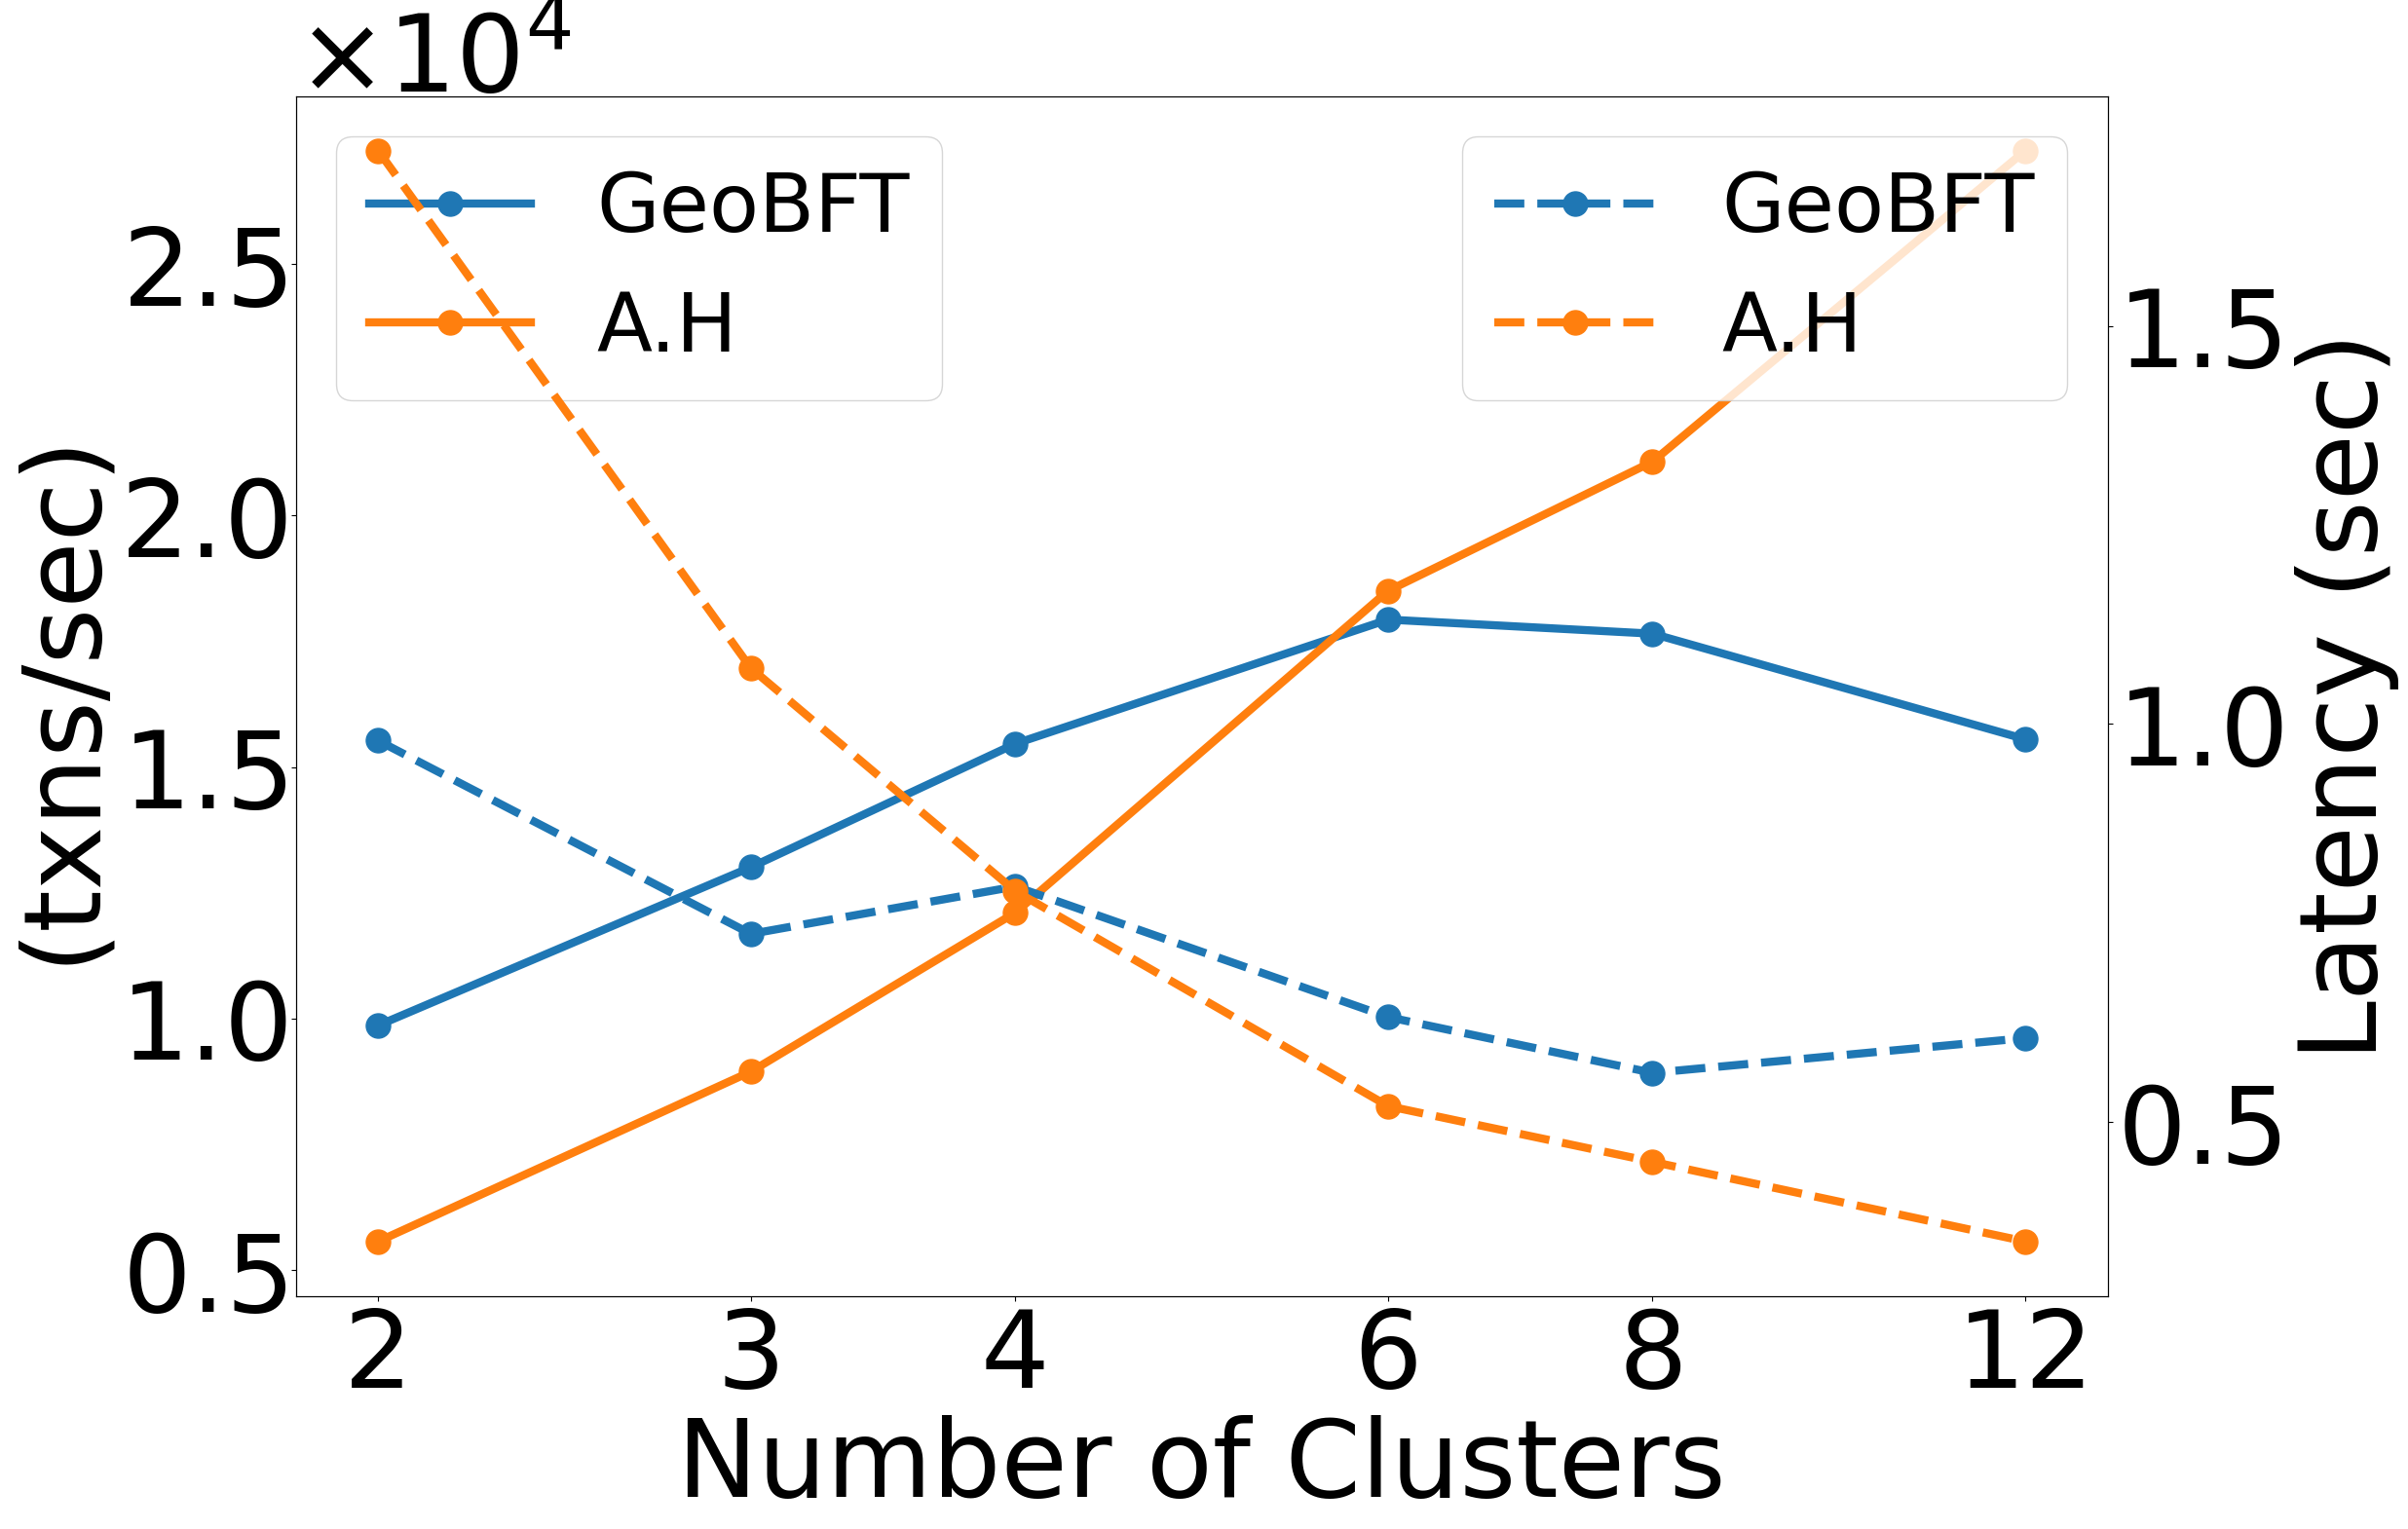

<Figure size 640x480 with 0 Axes>

In [57]:
fig, ax1 = pl.subplots(figsize=(24, 16))
ax1.plot([2, 3, 4, 6, 8, 12], resdb_thputs_geo_24, '-o', label='GeoBFT', markersize = 18, linewidth=6)
ax1.plot([2, 3, 4, 6, 8, 12], hs_thputs_24_geo, '-o', label='A.H', markersize = 18, linewidth=6)

ax1.legend(fontsize=45)
ax1.set_xscale('log')
ax1.yaxis.set_major_formatter(formatter)

# Define and set only specific tick positions
ticks = [2, 3, 4, 6, 8, 12]

ax1.set_xticks(ticks)
ax1.set_xticklabels([str(tick) for tick in ticks])


pl.xlabel('Number of Clusters')
ax1.set_ylabel('(txns/sec)')

# Ensure no unwanted minor ticks appear
ax1.xaxis.set_minor_locator(pl.NullLocator())  
ax1.xaxis.set_major_formatter(pl.ScalarFormatter())  

ax2 = ax1.twinx()



ax2.plot([2, 3, 4, 6, 8, 12], resdb_lats_geo_24, '--o', label='GeoBFT', markersize = 18, linewidth=6)
ax2.plot([2, 3, 4, 6, 8, 12], hs_lats_24_geo, '--o', label='A.H', markersize = 18, linewidth=6)
# ax.plot([12, 6, 3], bft_mc_lats, '-o', label='Ava-BftSmart')

# ax.plot([12, 6, 3], resdb_thputs_geo, '-*', markersize=15, label='geoBFT geo distributed')

ax1.legend(fontsize=60)
ax2.legend(fontsize=60)

# ax2.set_xscale('log')
# ax2.yaxis.set_major_formatter(formatter)

# Define and set only specific tick positions

# pl.xlabel('Number of Clusters')
ax2.set_ylabel('Latency (sec)')
# Ensure no unwanted minor ticks appear
# ax2.xaxis.set_minor_locator(pl.NullLocator())  
# ax2.xaxis.set_major_formatter(pl.ScalarFormatter())

pl.savefig('/home/tejas/Desktop/icde_graph1_thputslats_geo.pdf', dpi = 150, bbox_inches='tight' )

pl.show()
pl.clf()

In [26]:
# fig, ax = pl.subplots(figsize=(24, 16))
# ax.plot([2, 3, 4, 6, 8, 12], resdb_thputs_geo_24, '-o', label='GeoBFT', markersize = 18, linewidth=6)
# ax.plot([2, 3, 4, 6, 8, 12], hs_thputs_24_geo, '-o', label='A.H', markersize = 18, linewidth=6)

# ax.legend(fontsize=45)
# ax.set_xscale('log')
# ax.yaxis.set_major_formatter(formatter)

# # Define and set only specific tick positions
# ticks = [2, 3, 4, 6, 8, 12]
# ax.set_xticks(ticks)
# ax.set_xticklabels([str(tick) for tick in ticks])
# pl.xlabel('Number of Clusters')
# pl.ylabel('(txns/sec)')

# # Ensure no unwanted minor ticks appear
# ax.xaxis.set_minor_locator(pl.NullLocator())  
# ax.xaxis.set_major_formatter(pl.ScalarFormatter())  
# pl.savefig('/home/tejas/Desktop/icde_graph1_thputs_geo.png', dpi = 150, bbox_inches='tight' )

# pl.show()
# pl.clf()

In [27]:
# fig, ax = pl.subplots(figsize=(24, 16))
# ax.plot([2, 3, 4, 6, 8, 12], resdb_lats_geo_24, '-o', label='GeoBFT', markersize = 18, linewidth=6)
# ax.plot([2, 3, 4, 6, 8, 12], hs_lats_24_geo, '-o', label='A.H', markersize = 18, linewidth=6)

# # ax.plot([12, 6, 3], resdb_thputs_geo, '-*', markersize=15, label='geoBFT geo distributed')

# ax.legend(fontsize=45)
# ax.set_xscale('log')
# ax.yaxis.set_major_formatter(formatter)

# # Define and set only specific tick positions
# ticks = [2, 3, 4, 6, 8, 12]

# ax.set_xticks(ticks)
# ax.set_xticklabels([str(tick) for tick in ticks])
# pl.xlabel('Number of Clusters')
# pl.ylabel('Latency (sec)')
# # Ensure no unwanted minor ticks appear
# ax.xaxis.set_minor_locator(pl.NullLocator())  
# ax.xaxis.set_major_formatter(pl.ScalarFormatter())  
# # pl.savefig('/home/tejas/Desktop/icde_graph1_lats_geo.png', dpi = 150, bbox_inches='tight' )

# pl.show()
# pl.clf()

In [31]:
resdb_lats_geo_24,resdb_thputs_geo_24

([0.9790118562648239,
  0.7362919209199963,
  0.7958000519046858,
  0.6318087423029557,
  0.5617317101103053,
  0.6053866957538924],
 [9866.666666666666,
  13011.666666666666,
  15466.666666666666,
  17933.783333333333,
  17653.333333333332,
  15555.483333333334])

In [29]:
# resdb_thputs_geo_24[3] = 16988
# resdb_lats_geo_24[3] = 0.57

In [30]:
resdb_thputs_geo_24

[9866.666666666666,
 13011.666666666666,
 15466.666666666666,
 17933.783333333333,
 17653.333333333332,
 15555.483333333334]

In [18]:
hs_thputs_24_geo

[5572, 8948, 12109, 18506, 21073, 27255]